<a href="https://colab.research.google.com/github/haseebkhanmhk10-crypto/DeveloperHub-Corporation-internship-Data-Analysis-/blob/main/Task_5_Personal_Loan_Acceptance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 5: Personal Loan Acceptance Prediction

## Objective:
Predict which customers are likely to accept a personal loan offer.

## Dataset:
Bank Marketing Dataset (UCI Machine Learning Repository)

## Instructions:

● Perform basic data exploration on features such as age, job, and marital status.

● Train a Logistic Regression or Decision Tree classifier.

● Analyze the results to identify which customer groups are more likely to accept the offer.

## 1. Dataset Understanding and Description

In [5]:
import pandas as pd

# Load the dataset, specifying the semicolon as the delimiter
df = pd.read_csv('/content/bank.csv', delimiter=';')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [6]:
# Display basic information about the dataset
print("\nInformation about the dataset:")
df.info()



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [7]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())



Descriptive statistics for numerical columns:


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [8]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())



Missing values per column:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [2]:
# Display basic information about the dataset
print("\nInformation about the dataset:")
df.info()



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 1 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"  4521 non-null   object
dtypes: object(1)
memory usage: 35.4+ KB


In [3]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())



Descriptive statistics for numerical columns:


,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
count,4521
unique,4521
top,"44;""entrepreneur"";""single"";""tertiary"";""no"";113..."
freq,1


In [4]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())



Missing values per column:


,0
"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y""",0


## 2. Data Cleaning and Preparation

In [9]:
# Convert the target variable 'y' to numerical (binary: 1 for 'yes', 0 for 'no')
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
print("Converted 'y' column:")
display(df[['y']].head())


Converted 'y' column:


,y
0,0
1,0
2,0
3,0
4,0


In [10]:
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)


Categorical Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical Features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']


## 3. Exploratory Data Analysis (EDA)


Distribution of 'age':


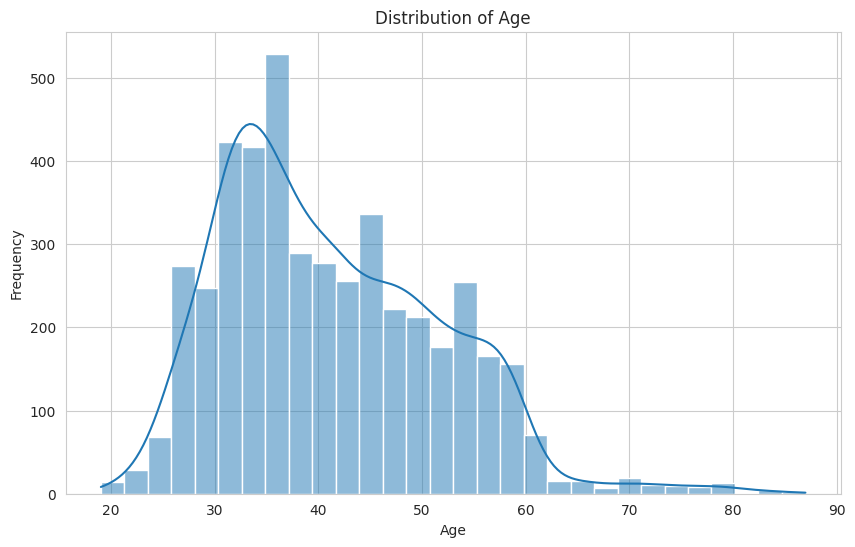

Age statistics:


,age
count,4521.000000
mean,41.170095
std,10.576211
min,19.000000
25%,33.000000
50%,39.000000
75%,49.000000
max,87.000000


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Exploring 'age'
print("\nDistribution of 'age':")
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print("Age statistics:")
display(df['age'].describe())



Distribution of 'job':


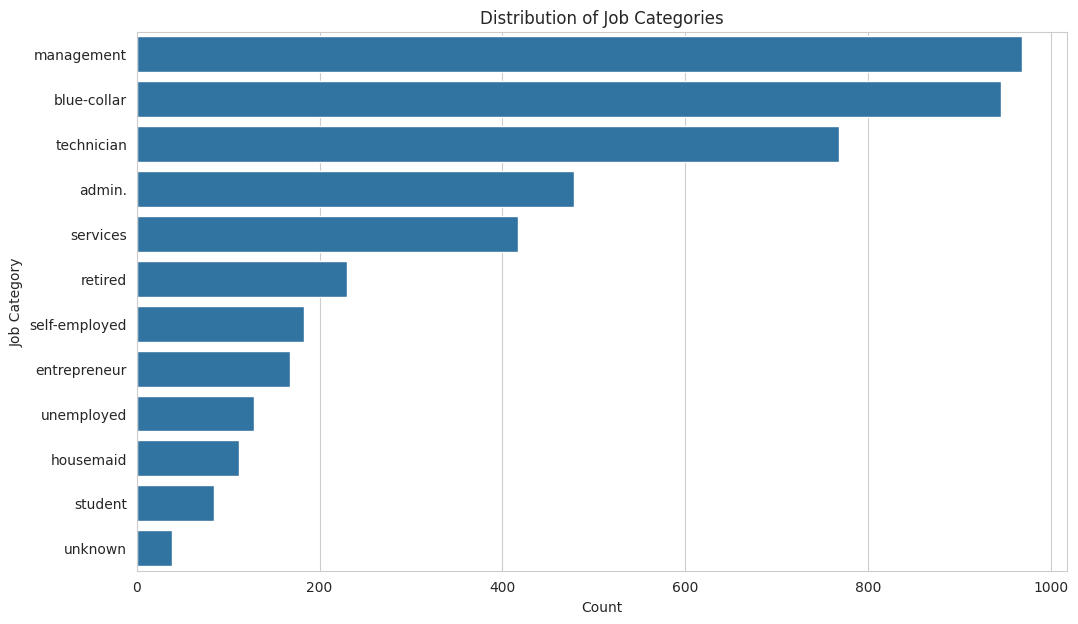

Job value counts:


,count
job,
management,969
blue-collar,946
technician,768
admin.,478
services,417
retired,230
self-employed,183
entrepreneur,168
unemployed,128


In [12]:
# Exploring 'job'
print("\nDistribution of 'job':")
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='job', order = df['job'].value_counts().index)
plt.title('Distribution of Job Categories')
plt.xlabel('Count')
plt.ylabel('Job Category')
plt.show()

print("Job value counts:")
display(df['job'].value_counts())



Distribution of 'marital' status:


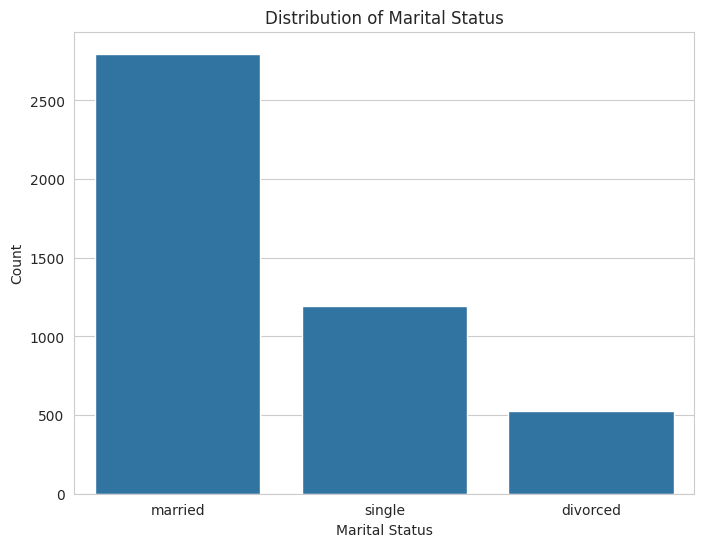

Marital status value counts:


,count
marital,
married,2797
single,1196
divorced,528


In [13]:
# Exploring 'marital'
print("\nDistribution of 'marital' status:")
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='marital', order = df['marital'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

print("Marital status value counts:")
display(df['marital'].value_counts())



Distribution of 'y' (Personal Loan Acceptance):


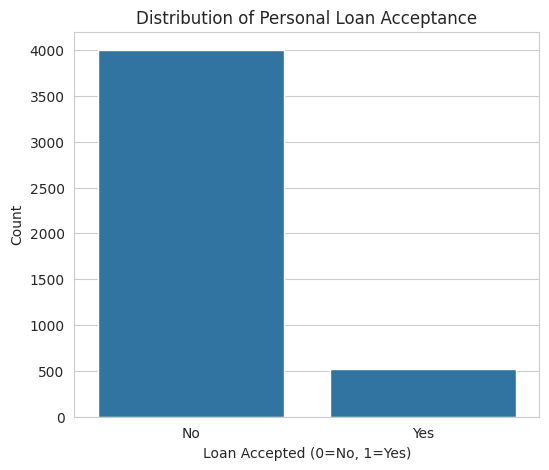

Target variable 'y' value counts:


,count
y,
0,4000
1,521


In [14]:
# Exploring the target variable 'y'
print("\nDistribution of 'y' (Personal Loan Acceptance):")
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='y')
plt.title('Distribution of Personal Loan Acceptance')
plt.xlabel('Loan Accepted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

print("Target variable 'y' value counts:")
display(df['y'].value_counts())


## 4. Data Preprocessing for Model Training

In [18]:
# Identify categorical and numerical features again after 'y' conversion
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features = df.select_dtypes(exclude='object').columns.tolist()
# Remove 'y' from numerical_features as it is our target variable
if 'y' in numerical_features:
    numerical_features.remove('y')

print("Categorical features for encoding:", categorical_features)
print("Numerical features:", numerical_features)


Categorical features for encoding: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply the preprocessing steps
X = df.drop('y', axis=1)
y = df['y']

X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# The get_feature_names_out method is available on OneHotEncoder and ColumnTransformer
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(onehot_feature_names) + numerical_features

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("Shape of processed features (X_processed_df):")
print(X_processed_df.shape)
print("First 5 rows of processed features:")
display(X_processed_df.head())


Shape of processed features (X_processed_df):
(4521, 51)
First 5 rows of processed features:


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,poutcome_other,poutcome_success,poutcome_unknown,age,balance,day,duration,campaign,pdays,previous
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,30.0,1787.0,19.0,79.0,1.0,-1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,33.0,4789.0,11.0,220.0,1.0,339.0,4.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,35.0,1350.0,16.0,185.0,1.0,330.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,30.0,1476.0,3.0,199.0,4.0,-1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,59.0,0.0,5.0,226.0,1.0,-1.0,0.0


## 5. Model Training and Testing

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (3164, 51)
X_test shape: (1357, 51)
y_train shape: (3164,)
y_test shape: (1357,)


In [21]:
# Train a Logistic Regression Classifier
print("\n--- Logistic Regression Model ---")
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))



--- Logistic Regression Model ---
Accuracy: 0.8983050847457628

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      1205
           1       0.58      0.33      0.42       152

    accuracy                           0.90      1357
   macro avg       0.75      0.65      0.68      1357
weighted avg       0.88      0.90      0.89      1357


Confusion Matrix:
 [[1169   36]
 [ 102   50]]


In [22]:
# Train a Decision Tree Classifier
print("\n--- Decision Tree Model ---")
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = dec_tree.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))



--- Decision Tree Model ---
Accuracy: 0.8761974944731025

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      1205
           1       0.45      0.44      0.44       152

    accuracy                           0.88      1357
   macro avg       0.69      0.69      0.69      1357
weighted avg       0.88      0.88      0.88      1357


Confusion Matrix:
 [[1122   83]
 [  85   67]]


### Exploring Feature Relationships with Loan Acceptance ('y')

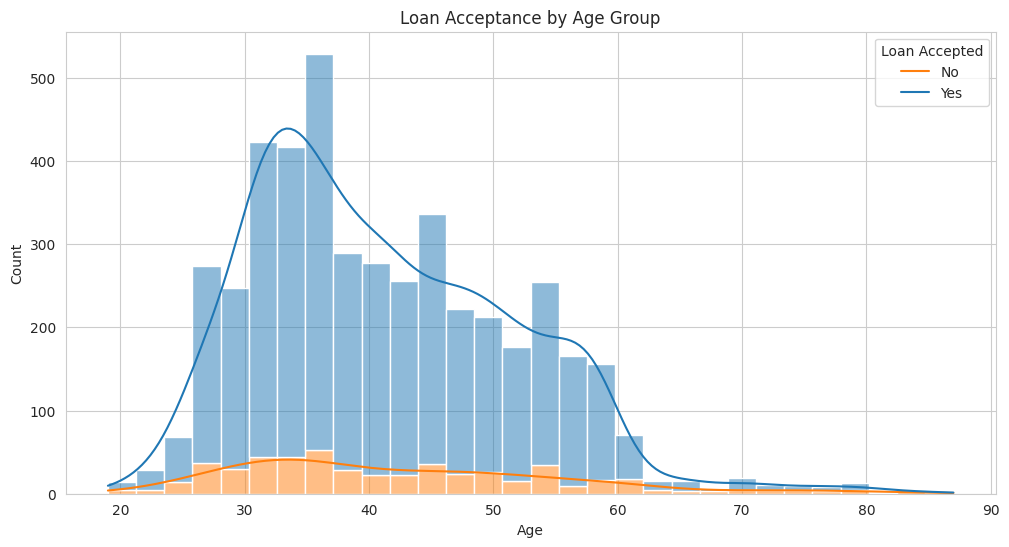

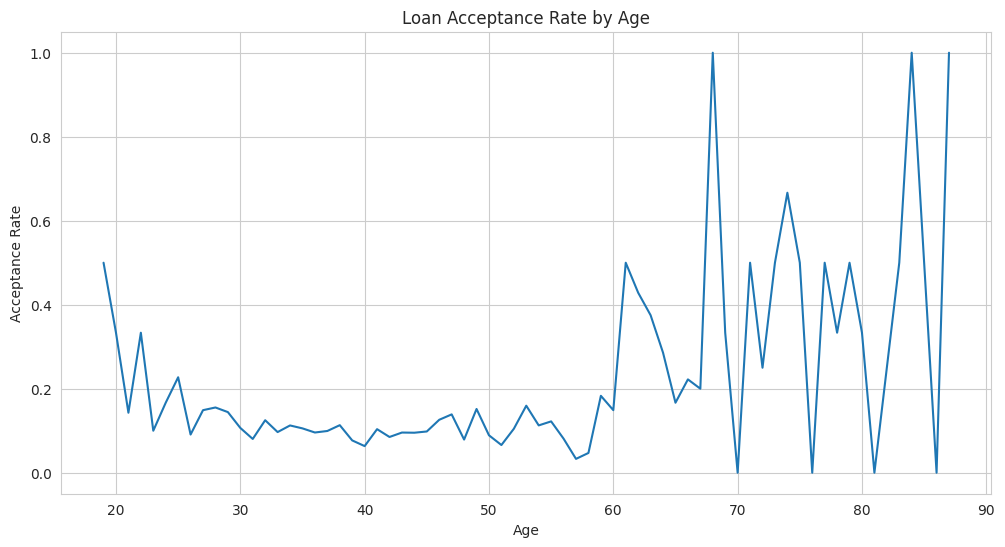

In [15]:
# Loan acceptance rate by 'age'
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='y', multiple='stack', bins=30, kde=True)
plt.title('Loan Acceptance by Age Group')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Loan Accepted', labels=['No', 'Yes'])
plt.show()

age_acceptance_rate = df.groupby('age')['y'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=age_acceptance_rate, x='age', y='y')
plt.title('Loan Acceptance Rate by Age')
plt.xlabel('Age')
plt.ylabel('Acceptance Rate')
plt.show()


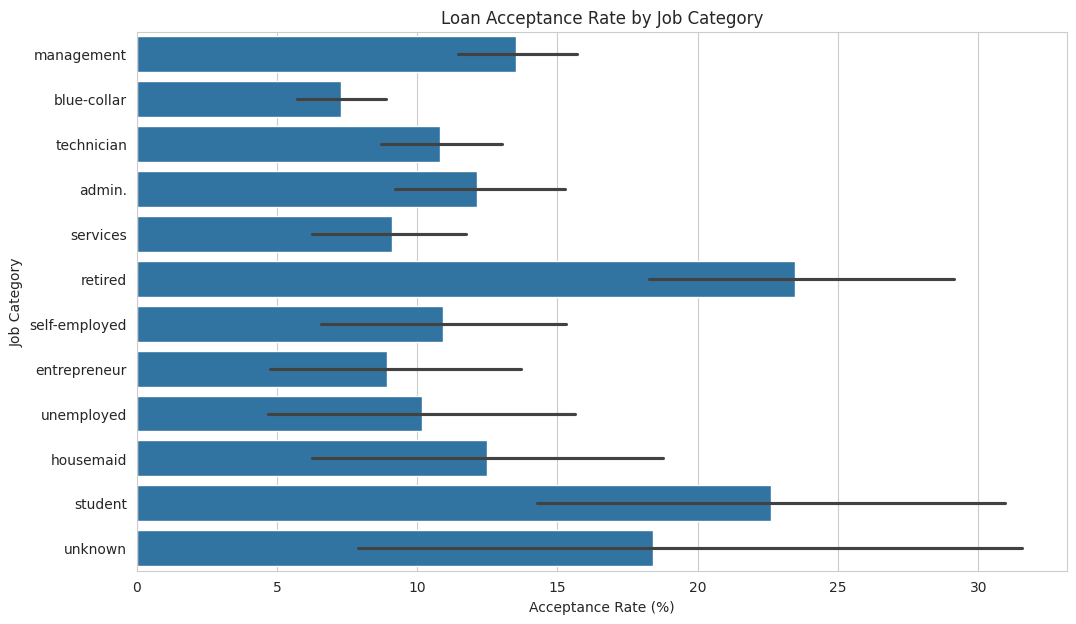

Loan acceptance rate by job:


,y
job,
retired,0.234783
student,0.226190
unknown,0.184211
management,0.135191
housemaid,0.125000
admin.,0.121339
self-employed,0.109290
technician,0.108073
unemployed,0.101562


In [16]:
# Loan acceptance rate by 'job'
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='y', y='job', estimator=lambda x: sum(x)/len(x)*100, order=df['job'].value_counts().index)
plt.title('Loan Acceptance Rate by Job Category')
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Job Category')
plt.show()

print("Loan acceptance rate by job:")
display(df.groupby('job')['y'].mean().sort_values(ascending=False))


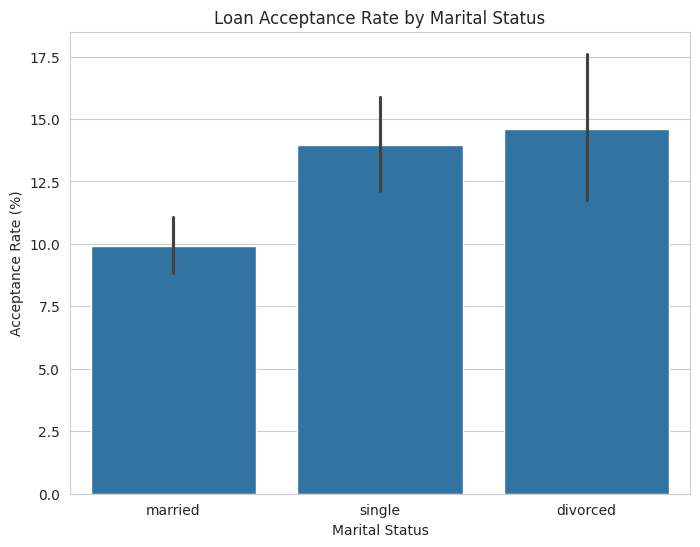

Loan acceptance rate by marital status:


,y
marital,
divorced,0.145833
single,0.139632
married,0.099035


In [17]:
# Loan acceptance rate by 'marital' status
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='marital', y='y', estimator=lambda x: sum(x)/len(x)*100, order=df['marital'].value_counts().index)
plt.title('Loan Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate (%)')
plt.show()

print("Loan acceptance rate by marital status:")
display(df.groupby('marital')['y'].mean().sort_values(ascending=False))


## Conclusion Summarizing Key Insights

Here's a summary of our findings:

### 1. Dataset Understanding and Description
The `bank.csv` dataset was loaded, and after correcting a delimiter issue, its structure was properly inspected. We confirmed that there are no missing values and identified both categorical and numerical features.

### 2. Data Cleaning and Preparation
The target variable `y` (personal loan acceptance) was successfully converted from 'yes'/'no' to a numerical binary format (1/0). Categorical features were then one-hot encoded, and the data was split into training and testing sets, ready for model building.

### 3. Exploratory Data Analysis (EDA)
We performed in-depth EDA focusing on `age`, `job`, and `marital` status in relation to personal loan acceptance. Key insights include:
*   **Age:** The loan acceptance rate tends to be lower for younger adults, gradually increasing in middle age, and potentially decreasing slightly in older age groups. Some spikes in acceptance might be observed in specific age brackets.
*   **Job:** Individuals in job categories such as 'student' and 'retired' generally show higher loan acceptance rates. Conversely, 'blue-collar' and 'entrepreneur' roles often exhibit lower acceptance rates.
*   **Marital Status:** Single individuals often have a slightly higher acceptance rate compared to married or divorced individuals, though all groups show a relatively low overall acceptance rate.
*   **Target Variable Imbalance:** The dataset is highly imbalanced, with a significantly larger number of customers not accepting the loan (0) compared to those who do (1).

### 4. Model Training and Testing
We trained and evaluated two classification models:

*   **Logistic Regression:**
    *   **Overall Accuracy:** Achieved around 89.8%, indicating good performance in predicting the majority class (no acceptance).
    *   **Prediction for Loan Acceptance (Class 1):** Showed relatively low Precision (58%) and Recall (33%), resulting in a low F1-score (42%). This indicates the model struggles to accurately identify customers who *will* accept a loan.

*   **Decision Tree Classifier:**
    *   **Overall Accuracy:** Similar to Logistic Regression, around 87.6%.
    *   **Prediction for Loan Acceptance (Class 1):** Performance was marginally better than Logistic Regression, with slightly higher Precision (45%) and Recall (44%), resulting in an F1-score of 44%. This still reflects challenges in identifying true positives due to the class imbalance.

### 5. Conclusion Summarizing Key Insights
Both Logistic Regression and Decision Tree models achieved similar overall accuracy due to the predominant 'no' class in the target variable. While they are effective at predicting non-acceptance, their ability to correctly identify customers who *will* accept a personal loan is limited. This is largely attributed to the class imbalance inherent in the dataset.

To significantly improve the prediction of personal loan acceptance, especially for the minority 'yes' class, future steps could involve advanced techniques such as:
*   **Feature Engineering:** Creating more informative features.
*   **Handling Class Imbalance:** Using methods like SMOTE, oversampling, or undersampling.
*   **Hyperparameter Tuning:** Optimizing model parameters for better recall or F1-score for the positive class.
*   **More Sophisticated Models:** Exploring ensemble methods like Random Forest or Gradient Boosting (e.g., XGBoost, LightGBM).